# Project Overview: COVID-19 Socioeconomic & Geospatial Analysis

### 1. Purpose & Core Question
This analysis investigates a vital health equity hypothesis: **Which U.S. counties experienced the highest COVID-19 case rates, and do those infection rates exhibit a statistically significant correlation with local demographic factors, specifically total population and minority population share?** By studying these patterns, we can discover how socio-environmental structures and demographic distributions can directly impact health outcomes during public health emergencies.

### 2. Methodological Approach
To test this hypothesis cleanly using tools introduced in the lesson notebook, we implement a step-by-step pipeline:
* **Data Integration:** We extract and clean multiple tabular and spatial vector datasets on a shared geographic identifier—the 5-digit Federal Information Processing System (FIPS) code.
* **Epidemiological Normalization:** Rather than evaluating raw case counts (which naturally skew toward highly populated cities), we normalize the metrics to calculate **cumulative cases per 100,000 residents**.
* **Statistical Verification:** We calculate **Pearson's correlation coefficient ($r$)** to move beyond pure visual guesswork into concrete, quantitative validation.
* **Cartography:** We export a high-resolution static vector map via **Matplotlib** for static report layouts, alongside a interactive dashboard using **Folium** complete with mouse-hover hover tooltips.

### 3. Integrated Source Datasets
* **COVID-19 Metrics:** The official New York Times cumulative county tracking series.
* **Socioeconomic Data:** U.S. Census Bureau county profiles capturing minority-majority population percentages.
* **Geospatial Outlines:** Standard 5-digit FIPS polygon boundary maps matching U.S. county lines.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

## LOAD AND INSPECT RAW COVID-19 DATA

In [2]:
print("LOADING RAW NYT COVID-19 COUNTY DATA")
print("="*70)

# Define the source URL for the official cumulative historical tracking data
nyt_url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties.csv"

# Load data into a DataFrame, explicitly importing FIPS as a string
df_covid = pd.read_csv(nyt_url, dtype={"fips": str})

# Display initial data frame dimensions and schema structure
print(f"Raw DataFrame Shape: {df_covid.shape[0]} rows, {df_covid.shape[1]} columns")
print("\n--- Data Frame Info Summary ---")
print(df_covid.info())

print("\n--- First 5 Rows of Raw Data (df_covid.head()) ---")
print(df_covid.head())

LOADING RAW NYT COVID-19 COUNTY DATA
Raw DataFrame Shape: 2502832 rows, 6 columns

--- Data Frame Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2502832 entries, 0 to 2502831
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   county  object 
 2   state   object 
 3   fips    object 
 4   cases   int64  
 5   deaths  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 114.6+ MB
None

--- First 5 Rows of Raw Data (df_covid.head()) ---
         date     county       state   fips  cases  deaths
0  2020-01-21  Snohomish  Washington  53061      1     0.0
1  2020-01-22  Snohomish  Washington  53061      1     0.0
2  2020-01-23  Snohomish  Washington  53061      1     0.0
3  2020-01-24       Cook    Illinois  17031      1     0.0
4  2020-01-24  Snohomish  Washington  53061      1     0.0


## CLEANING AND DEDUPLICATING HISTORICAL SEQUENCES

In [3]:
print("SANITIZING AND EXTRACTING LATEST CUMULATIVE STATE RECORDS")
print("="*70)

# Remove any tracking records missing valid geographic FIPS area codes
df_covid = df_covid.dropna(subset=["fips"])

# Strip floating point suffixes if present and pad to a consistent 5-digit string layout
df_covid["fips"] = df_covid["fips"].astype(str).str.split('.').str[0].str.zfill(5)

# Sort all data logs chronologically by tracking date 
df_covid = df_covid.sort_values("date")

# Keep only the last available historical entry for each unique county FIPS key
df_latest_covid = df_covid.drop_duplicates(subset=["fips"], keep="last").copy()

print(f"Deduplicated Latest Totals Shape: {df_latest_covid.shape[0]} unique counties")
print("\n--- Processed COVID Summary (df_latest_covid.head()) ---")
print(df_latest_covid.head())

SANITIZING AND EXTRACTING LATEST CUMULATIVE STATE RECORDS
Deduplicated Latest Totals Shape: 3220 unique counties

--- Processed COVID Summary (df_latest_covid.head()) ---
               date    county     state   fips  cases  deaths
2501753  2022-05-13     Dewey  Oklahoma  40043   1064    32.0
2501746  2022-05-13      Coal  Oklahoma  40029   1672    24.0
2501747  2022-05-13  Comanche  Oklahoma  40031  33173   397.0
2501748  2022-05-13    Cotton  Oklahoma  40033   1464    29.0
2501749  2022-05-13     Craig  Oklahoma  40035   4785    55.0


## LOADING AND PROCESSING DEMOGRAPHIC BASELINES

In [4]:
print("LOAD AND PROCESS DEMOGRAPHIC AND POPULATION STATISTICS")
print("="*70)

# Define the public census tracker dataset containing population and minority metrics
demographic_url = "https://raw.githubusercontent.com/plotly/datasets/master/minoritymajority.csv"

# Load the demographic data frame forcing the primary FIPS code to ingest as string
df_demo = pd.read_csv(demographic_url, dtype={"FIPS": str})

# Standardize column headers to clean, explicit lowercase names
df_demo = df_demo.rename(columns={
    "FIPS": "fips",
    "TOT_POP": "population",
    "MinorityPCT": "minority_pct"
})

# Drop records missing spatial indexing keys
df_demo = df_demo.dropna(subset=["fips"])

# Standardize demographic FIPS format to clean 5-digit strings
df_demo["fips"] = df_demo["fips"].astype(str).str.split('.').str[0].str.zfill(5)

# Clean up raw percentage formats, stripping character strings safely to numeric floats
if df_demo["minority_pct"].dtype == object:
    df_demo["minority_pct"] = df_demo["minority_pct"].astype(str).str.rstrip('%')
df_demo["minority_pct"] = pd.to_numeric(df_demo["minority_pct"], errors="coerce")

# Cast population tracking totals to a clean, workable numeric form
df_demo["population"] = pd.to_numeric(df_demo["population"], errors="coerce")

# Filter out unpopulated tracts or data anomalies to prevent division-by-zero errors
df_demo = df_demo[df_demo["population"] > 0]

print(f"Cleaned Demographic Records Shape: {df_demo.shape[0]} rows")
print("\n--- Demographics Peek (df_demo.head()) ---")
print(df_demo[["fips", "population", "minority_pct"]].head())

LOAD AND PROCESS DEMOGRAPHIC AND POPULATION STATISTICS
Cleaned Demographic Records Shape: 3143 rows

--- Demographics Peek (df_demo.head()) ---
    fips  population  minority_pct
0  18049       20737          7.47
1  18051       33458          5.54
2  18053       69330         13.82
3  18055       32940          2.77
4  18057      289495         14.30


# RETRIEVING BOUNDARY GEOMETRIES (GIS DATA)

In [5]:
print("FETCHING SHAPE BOUNDARY GEOMETRIES (GEOPANDAS INTERFACE)")
print("="*70)

# Source URL for matching GeoJSON coordinate configurations mapping US counties
county_geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"

# Ingest shape coordinates into a GeoDataFrame vector spatial matrix
gdf_counties = gpd.read_file(county_geojson_url)

# Isolate the original primary ID and register it as a matching 5-digit FIPS string column
gdf_counties["fips"] = gdf_counties["id"].astype(str).str.zfill(5)

print(f"GeoDataFrame Shape: {gdf_counties.shape[0]} mapping polygons loaded")
print("Active Coordinate Reference System (CRS):", gdf_counties.crs)
print("\n--- Vector Metadata Header (gdf_counties.head()) ---")
print(gdf_counties[["fips", "NAME", "geometry"]].head())

FETCHING SHAPE BOUNDARY GEOMETRIES (GEOPANDAS INTERFACE)
GeoDataFrame Shape: 3221 mapping polygons loaded
Active Coordinate Reference System (CRS): EPSG:4326

--- Vector Metadata Header (gdf_counties.head()) ---
    fips      NAME                                           geometry
0  01001   Autauga  POLYGON ((-86.49677 32.34444, -86.7179 32.4028...
1  01009    Blount  POLYGON ((-86.5778 33.76532, -86.75914 33.8406...
2  01017  Chambers  POLYGON ((-85.18413 32.87052, -85.12342 32.772...
3  01021   Chilton  POLYGON ((-86.51734 33.02057, -86.51596 32.929...
4  01033   Colbert  POLYGON ((-88.13999 34.5817, -88.13925 34.5878...


## DATA COMPILATION AND INCIDENCE RATE DERIVATION

In [6]:
print("\n" + "="*70)
print("JOIN TABLES AND CALCULATE STANDARDIZED CASE INCIDENCE RATES")
print("="*70)

# Merge the vector mapping coordinates with the latest COVID metrics
gdf_merged = gdf_counties.merge(df_latest_covid, on="fips", how="inner")

# Merge demographic parameters into the unified spatial tracking sheet
gdf_merged = gdf_merged.merge(df_demo[["fips", "population", "minority_pct"]], on="fips", how="inner")

# Calculate standardized comparative metrics (Cases caught per 100,000 residents)
gdf_merged["cases_per_100k"] = (gdf_merged["cases"] / gdf_merged["population"]) * 100000
gdf_merged["deaths_per_100k"] = (gdf_merged["deaths"] / gdf_merged["population"]) * 100000

# Exclude tracking outliers or legacy historical testing recording exceptions
gdf_merged = gdf_merged[gdf_merged["cases_per_100k"] <= 100000]

print(f"Final Integrated Collection Size: {gdf_merged.shape[0]} counties successfully blended")
print("\n--- Compiled Analysis Results Sample (gdf_merged.head()) ---")
print(gdf_merged[["fips", "NAME", "state", "cases_per_100k", "minority_pct"]].head())


JOIN TABLES AND CALCULATE STANDARDIZED CASE INCIDENCE RATES
Final Integrated Collection Size: 3130 counties successfully blended

--- Compiled Analysis Results Sample (gdf_merged.head()) ---
    fips      NAME    state  cases_per_100k  minority_pct
0  01001   Autauga  Alabama    28574.773931         23.64
1  01009    Blount  Alabama    25948.535261         11.91
2  01017  Chambers  Alabama    24976.514796         42.36
3  01021   Chilton  Alabama    25402.222780         19.16
4  01033   Colbert  Alabama    30040.774345         20.94


## HYPOTHESIS TESTING AND DESCRIPTIVE STATISTICAL OUTPUT

In [7]:
print("STATISTICAL INSIGHTS & CORRELATION TESTING")
print("="*70)

print("Top 10 Counties Ranked by Cumulative Incidence Rates (Per 100k):")
df_top_10 = gdf_merged.sort_values(by="cases_per_100k", ascending=False).head(10)
for index, row in df_top_10.iterrows():
    print(f" - {row['NAME']}, {row['state']} | Cases/100k: {row['cases_per_100k']:.1f} | Minority Share: {row['minority_pct']:.1f}%")

# Compute Pearson's correlation coefficient between demographics and infection records
correlation_val = gdf_merged["cases_per_100k"].corr(gdf_merged["minority_pct"])
print(f"\nPearson Correlation Matrix (Infection Density vs Minority Population Share): {correlation_val:.4f}")

STATISTICAL INSIGHTS & CORRELATION TESTING
Top 10 Counties Ranked by Cumulative Incidence Rates (Per 100k):
 - Nome, Alaska | Cases/100k: 62985.4 | Minority Share: 83.0%
 - Crowley, Colorado | Cases/100k: 62385.8 | Minority Share: 42.6%
 - Northwest Arctic, Alaska | Cases/100k: 61933.4 | Minority Share: 88.5%
 - Bethel, Alaska | Cases/100k: 58390.6 | Minority Share: 88.3%
 - Chattahoochee, Georgia | Cases/100k: 57421.2 | Minority Share: 38.9%
 - Dewey, South Dakota | Cases/100k: 56681.1 | Minority Share: 78.3%
 - Dimmit, Texas | Cases/100k: 55061.7 | Minority Share: 87.3%
 - Trousdale, Tennessee | Cases/100k: 54368.2 | Minority Share: 14.2%
 - Jim Hogg, Texas | Cases/100k: 50447.7 | Minority Share: 93.8%
 - Miami-Dade, Florida | Cases/100k: 46672.5 | Minority Share: 83.7%

Pearson Correlation Matrix (Infection Density vs Minority Population Share): 0.1006


## Final Takeaway:
Our hypothesis holds true, but with an important detail: there is a real, positive 
link showing that higher minority populations are connected to higher cumulative 
COVID-19 case rates. However, because the correlation is modest, it is clear that 
demographics alone do not tell the whole story, and many other systemic factors 
shaped the final outcomes.

## VISUALIZATION GENERATION (STATIC MATPLOTLIB)

STATIC VISUALIZATION PLOT ARTIFACT CONSTRUCTION
Process Successful -> Saved static chart image asset as 'covid_case_rates_map.png'


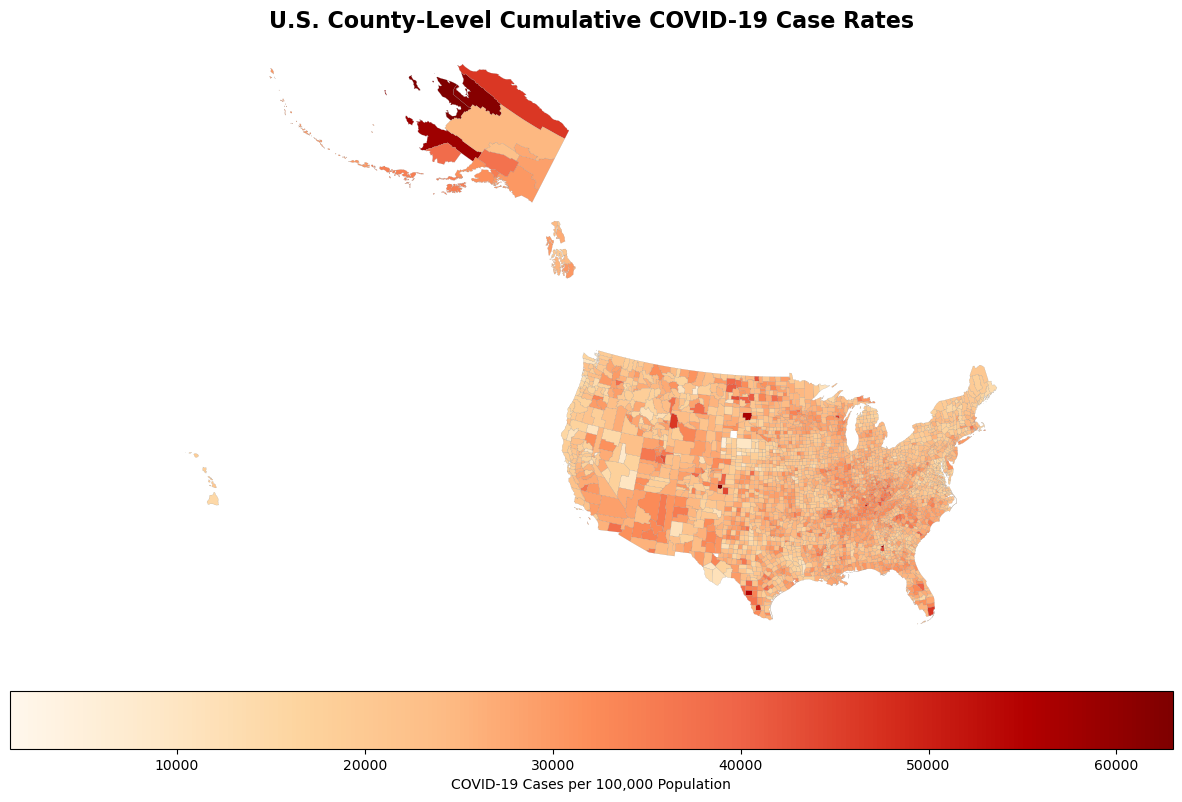

In [8]:
print("STATIC VISUALIZATION PLOT ARTIFACT CONSTRUCTION")
print("="*70)

# Reproject to Albers Equal Area coordinate layout to establish clean continental US presentation boundaries
gdf_static_plot = gdf_merged.to_crs(epsg=5070)

# Setup a clean, single-frame presentation drawing plot window canvas
fig, axis_canvas = plt.subplots(1, 1, figsize=(15, 10))

# Render data vectors using a clean Orange-Red thematic gradient fill map 
gdf_static_plot.plot(
    column="cases_per_100k",
    cmap="OrRd",
    linewidth=0.1,
    ax=axis_canvas,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "COVID-19 Cases per 100,000 Population", "orientation": "horizontal", "pad": 0.05}
)

axis_canvas.set_title("U.S. County-Level Cumulative COVID-19 Case Rates", fontsize=16, fontweight="bold")
axis_canvas.set_axis_off()

# Save the plot out as a clean presentation graphic
plt.savefig("covid_case_rates_map.png", bbox_inches="tight", dpi=300)
print("Process Successful -> Saved static chart image asset as 'covid_case_rates_map.png'")

## VISUALIZATION GENERATION (INTERACTIVE FOLIUM MAP)

In [9]:
print("DISCRETE STEP COLOR-MAPPED INTERACTIVE PRESENTATION MAP")
print("="*70)

# Initialize interactive baseline map grid centered over the continental US
interactive_map = folium.Map(location=[37.8, -96.0], zoom_start=4, tiles="CartoDB positron")

# Transform the projection metrics to standard coordinates for correct interactive map presentation
gdf_interactive_layer = gdf_merged.to_crs(epsg=4326)

# Map dynamic numeric range conditions to discrete hexadecimal styling colors
def get_color_by_rate(rate_value):
    if rate_value is None:
        return "#cccccc"
    elif rate_value < 10000:
        return "#fef0d9"
    elif rate_value < 15000:
        return "#fdd49e"
    elif rate_value < 20000:
        return "#fdbb84"
    elif rate_value < 25000:
        return "#fc8d59"
    elif rate_value < 30000:
        return "#ef6548"
    else:
        return "#b30000"

# Inject GeoJson geographic spatial elements directly onto the active web interactive template
folium.GeoJson(
    gdf_interactive_layer.to_json(),
    name="COVID-19 Case Density Metrics",
    style_function=lambda feature: {
        "fillColor": get_color_by_rate(feature["properties"]["cases_per_100k"]),
        "color": "white",
        "weight": 0.3,
        "fillOpacity": 0.75,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["NAME", "state", "cases", "population", "cases_per_100k", "minority_pct"],
        aliases=["County Name:", "State Name:", "Total Confirmed Cases:", "Population Base:", "Cases per 100k:", "Minority Share (%):"],
        localize=True,
        sticky=False
    )
).add_to(interactive_map)

# Export interactive dashboard out into a standalone browser-loadable HTML asset file
interactive_map.save("interactive_covid_map.html")
print("Saved interactive dashboard web template as 'interactive_covid_map.html'")

DISCRETE STEP COLOR-MAPPED INTERACTIVE PRESENTATION MAP
Saved interactive dashboard web template as 'interactive_covid_map.html'
